In [1]:
import sys

sys.path.append('..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torchvision import transforms

from virtuesm2.models.virtuesm2_hf import VirTuesM2_HF
from virtuesm2.utils.utils import load_marker_embedding_dict, load_marker_embeddings
from virtuesm2.virtual_staining.virtuesm2_vstaining_hf import VM2_VirtualStaining_HF
from scipy.stats import pearsonr

/mnt/aimm/scratch/querfurth/code/virtues-world/virtues-m2/virtuesm2/models/layers/swiglu_ffn.py:38: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/mnt/aimm/scratch/querfurth/code/virtues-world/virtues-m2/virtuesm2/models/layers/attention_qkv_separate.py:17: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
2026-08-28 17:47:03.534 | INFO     | virtuesm2.models.layers:<module>:22 - Using xformers version 0.0.29.post3 for attention layers.


### VirTual Staining example

This notebook demonstrates how we can infer new markers from the H&E input. For this, we first load the frozen VirTues-M2 model, construct the VirTues-inspired decoder and attach it to the outputs of VirTues-M2.

Using the encoded H&E image, we condition our virtual staining decoder using masking tokens to which the corresponding esm embedding of the marker of interest is added. We repeat this process for every marker.

#### Load the multiplex and H&E sample crop

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

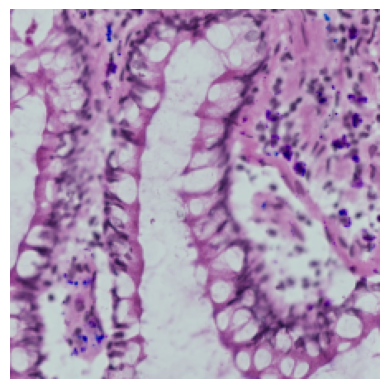

In [2]:
mx_image_raw = np.load("../example_data/mx_example_crop_3.npy")
mx_image_raw = torch.tensor(mx_image_raw)
he_image_raw = np.array(Image.open("../example_data/he_example_crop_3.png").convert("RGB"))
he_image_raw = torch.tensor(he_image_raw)
plt.imshow(he_image_raw)
plt.axis("off")

#### Load ESM-2 embeddings

In [3]:
esm_embedding_dict = load_marker_embedding_dict("../example_data/esm_embeddings")
esm_embeddings = load_marker_embeddings("../example_data/esm_embeddings")

# esm embeddings for channels
marker_names = pd.read_csv("../example_data/gene_dict_hickey2023organization.csv")

In [4]:
marker_names.loc[marker_names["name"] == "DRAQ5", "uniprot_id"] = "Exclude"
mx_image = mx_image_raw[marker_names["uniprot_id"].values != "Exclude"]
uniprot_ids = marker_names["uniprot_id"].values[marker_names["uniprot_id"].values != "Exclude"]
target_uniprot_ids = ['P68431', 'Q04695', 'P16284', 'P46013', 'P08575', 'P34810', 'Q86VB7', 'P07766', 'P01730', 'P01732', 'P08575-4']

#### Apply Normalization

In [5]:
mean_he = [0.7068, 0.5755, 0.722]
std_he = [0.195, 0.2316, 0.1816]
he_normalization = transforms.Normalize(mean=mean_he, std=std_he)

In [6]:
he_image = he_normalization(he_image_raw.permute(2,0,1)/255.0)
pos = {u: i for i, u in enumerate(uniprot_ids)}
idx = [pos[u] for u in target_uniprot_ids]
mx_image = mx_image[idx]

#### Create Model

In [7]:
vm2_encoder = VirTuesM2_HF.from_pretrained("bunnelab/virtues-m2", marker_embedding_dir="../example_data/esm_embeddings", revision="v2")

vstaining_model = VM2_VirtualStaining_HF.from_pretrained(
            "bunnelab/virtues-m2",
            vm2_encoder=vm2_encoder,
            marker_embedding_dir="../example_data/esm_embeddings",
            mode = "he",
            revision="v2",
        )
vstaining_model.eval()
vstaining_model.cuda()

VM2_VirtualStaining_HF(
  (model): VirTuesM2_HF(
    (he_embed_layer): PatchEmbed(
      (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
      (norm): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
    )
    (mx_embed_layer): MultiplexTokenizer(
      (protein_encoder): Linear(in_features=640, out_features=1024, bias=True)
      (multiplex_patch_encoder): Linear(in_features=196, out_features=1024, bias=True)
      (layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (encoder): ModuleList(
        (0): MarkerAttentionEncoderBlock(
          (encoder_layer): TransformerEncoder(
            (layers): ModuleList(
              (0-1): 2 x TransformerEncoderBlock(
                (multi_head_attention): MHAwithPosEmb(
                  (W_q): Linear(in_features=1024, out_features=1024, bias=True)
                  (W_k): Linear(in_features=1024, out_features=1024, bias=True)
                  (W_v): Linear(in_features=1024, out_features=1024, bias

#### Encode the H&E + Virtually stain it

In [8]:
output = vstaining_model.forward([{
    "mx": None,
    "he": he_image,
    "target_uniprot_ids": target_uniprot_ids
}])

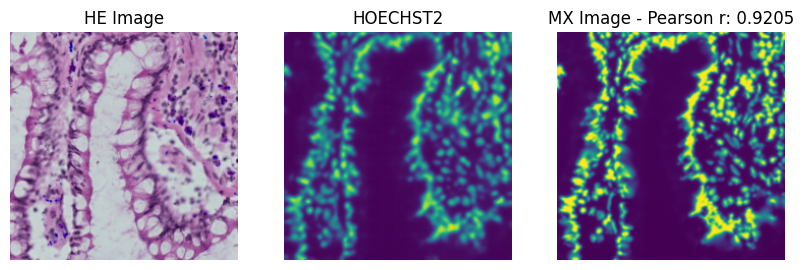

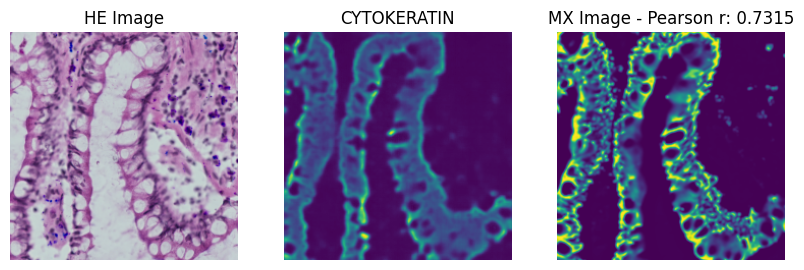

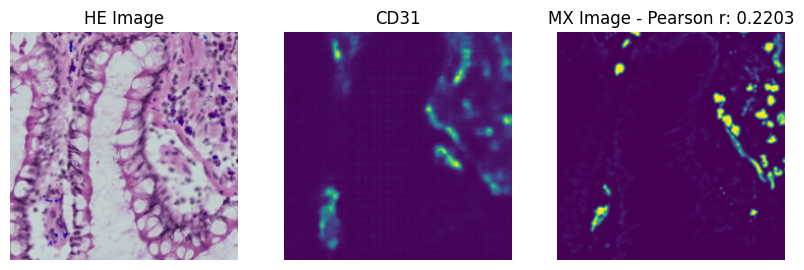

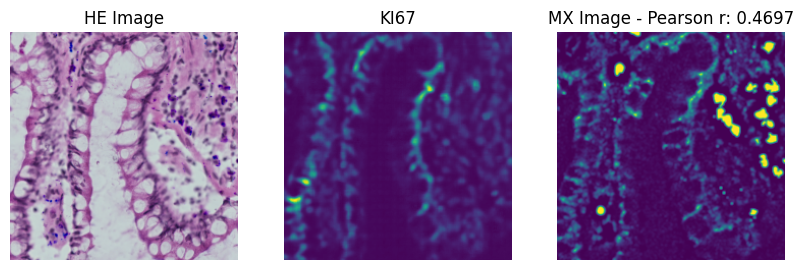

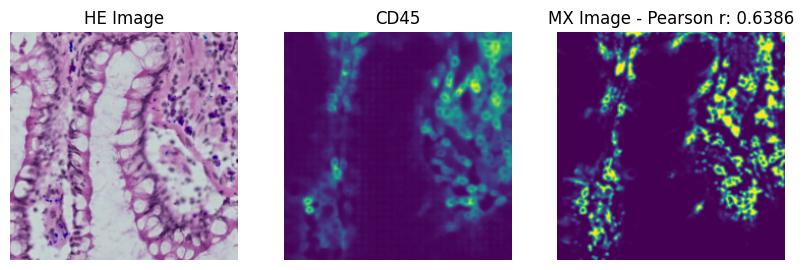

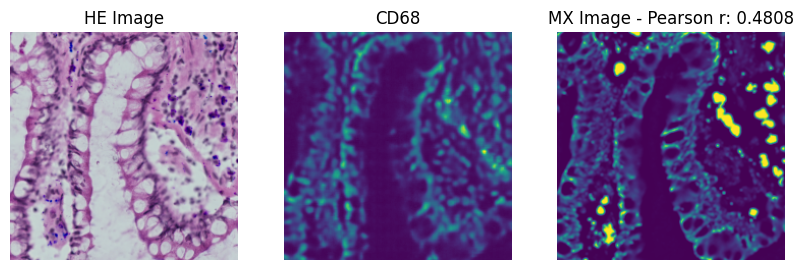

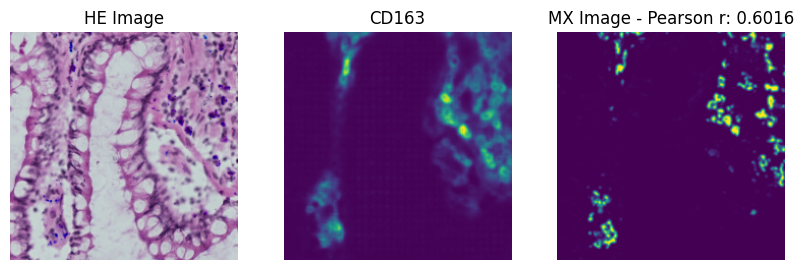

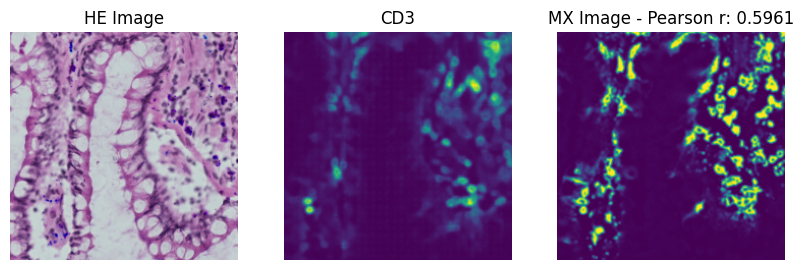

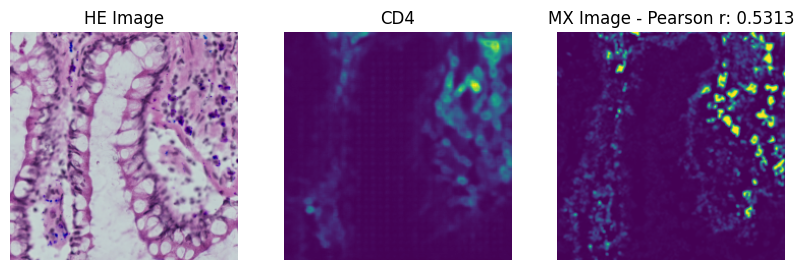

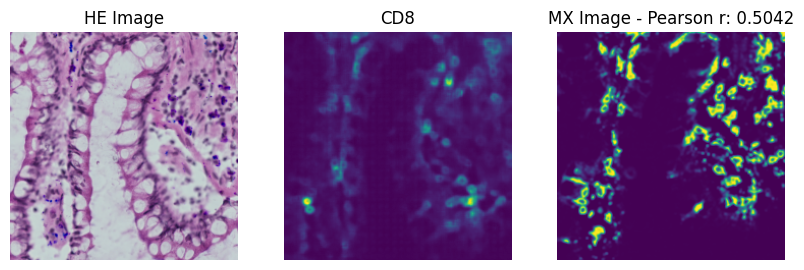

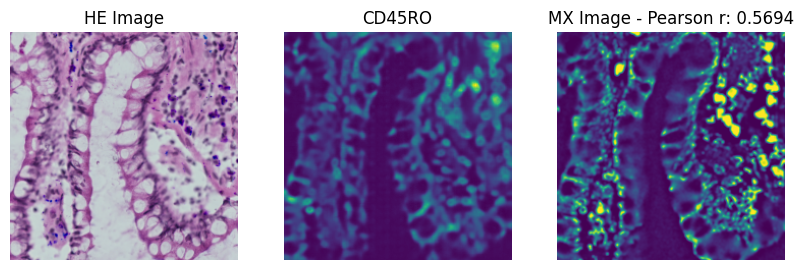

In [9]:
# show virtual stains and pearson correlation with mx images
virtual_stain = output[0].cpu().numpy()

for i in range(len(target_uniprot_ids)):
    fig, axs = plt.subplots(1,3, figsize=(10, 10))
    axs[0].imshow(he_image_raw)
    axs[0].set_title("HE Image")
    axs[0].axis("off")
    axs[1].imshow(virtual_stain[i])
    axs[1].set_title(marker_names.loc[marker_names["uniprot_id"] == target_uniprot_ids[i], "name"].item())
    axs[1].axis("off")
    axs[2].imshow(mx_image[i])
    axs[2].axis("off")
    axs[2].set_title(f"MX Image - Pearson r: {pearsonr(virtual_stain[i].flatten(), mx_image[i].cpu().numpy().flatten())[0]:.4f}")
    plt.show()